# Capstone Project - Proyecto Final – Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombres de los integrantes del grupo** | Madeleine Sabrera Napa |
| **Título del Proyecto** |  Predicción del Rendimiento Académico de Estudiantes mediante un Pipeline de Machine Learning|
| **Fecha de Entrega** |19/02/2026 |

---

## Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo
---

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de predecir el rendimiento académico de estudiantes, medido a través del GPA (Grade Point Average), utilizando técnicas de Deep Learning aplicadas a datos tabulares.

Se trabajó con un dataset de aproximadamente 1 millón de registros y 21 variables, incorporando información demográfica, académica y del entorno del estudiante. Tras el preprocesamiento y la ingeniería de características, se diseñó una red neuronal densa (MLP) para resolver el problema de regresión.

El modelo alcanzó un:

*   MAE: 0.2375
*   MSE: 0.0882
*   RMSE: ≈ 0.30

Esto significa que el modelo predice el GPA con un error promedio menor a 0.3 puntos en una escala de 0 a 4, lo cual evidencia una capacidad predictiva adecuada para un primer enfoque con Deep Learning.

Desde el punto de vista de negocio, este modelo puede utilizarse para:

Identificar estudiantes en riesgo académico.

*  Diseñar intervenciones tempranas.
*  Optimizar programas de tutoría.
*  Mejorar la planificación académica institucional.
*  Identificar estudiantes en riesgo académico





---

## 2. Configuración del Entorno



### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [1]:
# Descomente e instale las librerías adicionales que necesite
# !pip install <nombre de la libreria>

### 2.3 Importación de Librerías

In [2]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(" Todas las librerías importadas correctamente")
print(f"   TensorFlow version: {tf.__version__}")

 Todas las librerías importadas correctamente
   TensorFlow version: 2.19.0


### 2.4 Conexión con Google Drive (para cargar datos)

In [3]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/Capstone_Project/'

print(f" Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Mounted at /content/drive
 Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/Capstone_Project/


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Industria / Sector**

El proyecto se enmarca en el sector educativo, específicamente en instituciones de educación secundaria y/o superior que buscan optimizar la gestión académica mediante el uso de analítica avanzada y modelos predictivos.

**Caso de Estudio**

El caso de estudio corresponde a una institución educativa (escenario académico simulado) que dispone de un amplio volumen de datos históricos de estudiantes, incluyendo variables demográficas, académicas y del entorno familiar. La institución busca aprovechar estos datos para fortalecer su toma de decisiones basada en evidencia.

**Situación Actual**

Actualmente, la institución evalúa el rendimiento académico de los estudiantes de manera reactiva, es decir, identifica bajo desempeño únicamente después de que los resultados académicos han sido publicados.

Esta situación genera varios desafíos:

*  Dificultad para anticipar estudiantes en riesgo.
*  Intervenciones tardías.
*   Uso ineficiente de recursos académicos.
*   Posible incremento en tasas de desaprobación o deserción.


A pesar de contar con grandes volúmenes de información (casi un millón de registros), la institución aún no utiliza modelos de Machine Learning para generar predicciones que permitan actuar de manera preventiva.


---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:

**¿Cuál es el problema específico?**

El problema consiste en predecir el rendimiento académico (GPA) de los estudiantes antes del cierre del período académico, utilizando variables demográficas, socioeconómicas y académicas disponibles en el dataset.

Se trata de un problema de regresión supervisada, donde la variable objetivo es el GPA (escala 0–4).

**¿Por qué es importante resolverlo**

Resolver este problema es fundamental porque permite:

*   Identificar estudiantes con probabilidad de bajo rendimiento.
*   Implementar tutorías y acompañamiento académico de manera anticipada.
*   Diseñar políticas educativas basadas en datos.
*   Mejorar indicadores institucionales de desempeño.

Desde una perspectiva estratégica, el uso de modelos predictivos transforma la gestión educativa de un enfoque reactivo a uno preventivo y proactivo.

**¿Cuál es el impacto actual del problema**

La ausencia de un sistema predictivo genera:



*   Intervenciones tardías cuando el bajo rendimiento ya se ha materializado.
*   Posible aumento en la tasa de deserción.
*   Menor eficiencia en la asignación de recursos académicos.
*   Impacto negativo en indicadores institucionales de calidad.

En términos cuantitativos, incluso una mejora promedio de 0.2–0.3 puntos en el GPA puede representar una diferencia significativa en tasas de aprobación y continuidad académica.

Por ello, el desarrollo de un modelo de Machine Learning que prediga el GPA con un error promedio menor a 0.3 puntos representa una herramienta estratégica para la toma de decisiones basada en datos.

### 3.3 Objetivos del Proyecto

**Objetivo General:**
Desarrollar un modelo de Machine Learning basado en una red neuronal densa (MLP) que permita predecir el GPA de los estudiantes con un error promedio (MAE) ≤ 0.30 puntos, utilizando un dataset de aproximadamente 1 millón de registros, antes del 19 de febrero de 2026, con el fin de apoyar la toma de decisiones académicas basadas en datos.

**Objetivos Específicos:**
1. Preprocesar el dataset aplicando técnicas de limpieza, codificación de variables categóricas y escalamiento, logrando un dataset estructurado con 100% de variables listas para modelamiento antes de la etapa de entrenamiento.

2. Diseñar e implementar una red neuronal densa (MLP) con al menos 3 capas ocultas, incorporando técnicas de regularización (Dropout y Batch Normalization), y entrenarla en un máximo de 30 épocas utilizando TensorFlow/Keras.

3. Evaluar el modelo utilizando métricas de regresión (MAE, MSE y RMSE), asegurando un desempeño mínimo de MAE ≤ 0.30 y RMSE ≤ 0.35 en el conjunto de prueba.

4. Validar la capacidad de generalización del modelo, mediante la división de datos en entrenamiento (70%), validación (15%) y prueba (15%), garantizando estabilidad entre métricas de validación y test.

5. Proponer recomendaciones de negocio basadas en los resultados, identificando cómo el modelo puede utilizarse para detectar estudiantes en riesgo y mejorar la gestión académica al cierre del proyecto.

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [ ] Clasificación binaria
- [ ] Clasificación multiclase
- [x] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Otro: _________

**Justificación:**
El problema consiste en predecir el valor del GPA, que es una variable numérica continua en una escala de 0 a 4.

No se trata de clasificar categorías (como aprobado/desaprobado), sino de estimar un valor cuantitativo específico.

Por lo tanto:

*   No es clasificación binaria (no hay solo dos clases).
*   No es clasificación multiclase (no se predicen categorías discretas).
*   No es clustering (no se busca agrupar estudiantes).
*   No es serie temporal (no se modela dependencia temporal secuencial).

El enfoque de regresión supervisada es el más adecuado porque:

- Existe una variable objetivo continua claramente definida (GPA).
- Se dispone de datos etiquetados.
- El objetivo es minimizar el error entre el valor real y el valor predicho.


---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [4]:
# =====================================================
# CARGA DE DATOS
# =====================================================

# Opción 1: Cargar desde Google Drive
# df = pd.read_csv(BASE_PATH + 'datos.csv')

# Opción 2: Cargar desde URL
# df = pd.read_csv('https://url-de-sus-datos.com/datos.csv')

# Opción 3: Cargar desde archivo local (subido a Colab)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('nombre_archivo.csv')

# Opción 4: Dataset de ejemplo (para testing)
# from sklearn.datasets import load_iris, load_boston, fetch_california_housing
# data = load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# =====================================================
# COMPLETE AQUÍ: Cargue su dataset
# =====================================================

df = pd.read_csv("/content/drive/MyDrive/Deep Learning Final/Dataset.csv")

print(f"Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Dataset cargado exitosamente
Dimensiones: 999,997 filas × 21 columnas


### 4.2 Descripción del Dataset

El dataset fue cargado desde Kagle:

Dimensiones: 999,997 filas × 21 columnas.

**Se realizó:**

- Visualización de las primeras filas.

- Revisión de tipos de datos.

- Estadísticos descriptivos.

- Análisis de la variable objetivo (GPA).

**Resultados clave:**

- No se encontraron valores faltantes.

- La variable GPA presenta una distribución continua adecuada para regresión.

- Existen múltiples variables numéricas y categóricas relevantes.

También se generó una matriz de correlación para identificar relaciones lineales entre variables y el GPA.



 Variable | Tipo | Descripción | Rol en ML | Transformación Aplicada |
|----------|------|-------------|-----------|--------------------------|
| Age | Numérica | Edad del estudiante | Input | Escalado con StandardScaler |
| Gender | Categórica | Género del estudiante | Input | One-Hot Encoding |
| Race | Categórica | Grupo étnico del estudiante | Input | One-Hot Encoding |
| ParentalEducation | Categórica | Nivel educativo de los padres | Input | One-Hot Encoding |
| StudyTimeWeekly | Numérica | Horas de estudio semanales | Input | Escalado con StandardScaler |
| Absences | Numérica | Número de inasistencias | Input | Escalado con StandardScaler |
| Tutoring | Categórica | Recibe tutorías | Input | One-Hot Encoding |
| ParentalSupport | Categórica | Apoyo familiar | Input | One-Hot Encoding |
| Extracurricular | Categórica | Actividades extracurriculares | Input | One-Hot Encoding |
| Sports | Categórica | Participación en deportes | Input | One-Hot Encoding |
| Music | Categórica | Participación musical | Input | One-Hot Encoding |
| Volunteering | Categórica | Participación en voluntariado | Input | One-Hot Encoding |
| GPA | Numérica | Promedio académico | Output | Transformación log1p |

---

### 4.3 Exploración Inicial de Datos (EDA)

In [5]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

display(df.head())
df.info()
display(df.describe())


,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,Female,White,1,HS,Public,City,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,Female,Hispanic,1,<HS,Private,City,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,Female,Black,2,HS,Public,Rural,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,Female,White,2,HS,Public,Town,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,Male,Black,3,Bachelors+,Public,Rural,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999997 entries, 0 to 999996
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999997 non-null  int64  
 1   Grade              999997 non-null  int64  
 2   Gender             999997 non-null  object 
 3   Race               999997 non-null  object 
 4   SES_Quartile       999997 non-null  int64  
 5   ParentalEducation  999997 non-null  object 
 6   SchoolType         999997 non-null  object 
 7   Locale             999997 non-null  object 
 8   TestScore_Math     999997 non-null  float64
 9   TestScore_Reading  999997 non-null  float64
 10  TestScore_Science  999997 non-null  float64
 11  GPA                999997 non-null  float64
 12  AttendanceRate     999997 non-null  float64
 13  StudyHours         999997 non-null  float64
 14  InternetAccess     999997 non-null  int64  
 15  Extracurricular    999997 non-null  int64  
 16  Pa

,Age,Grade,SES_Quartile,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
count,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000
mean,15.999193,10.799551,2.500284,74.980073,74.978168,74.983955,2.996760,0.899562,0.999933,0.850403,0.549809,0.180610,0.422772,0.200068,3.002909,2.072477
std,1.413712,1.165967,1.117889,9.944334,9.954602,9.946251,0.459472,0.048024,0.348642,0.356677,0.497513,0.384695,0.494000,0.400051,1.008419,0.919165
min,14.000000,9.000000,1.000000,29.146751,30.796723,26.915868,0.752867,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,10.000000,2.000000,68.248703,68.250126,68.264300,2.684924,0.866991,0.763883,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,16.000000,11.000000,3.000000,74.998702,74.985049,74.997447,2.999782,0.899881,0.999841,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,2.000000
75%,17.000000,12.000000,3.000000,81.750240,81.746642,81.739127,3.314308,0.932912,1.236215,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,3.000000
max,18.000000,12.000000,4.000000,100.000000,100.000000,100.000000,4.000000,1.000000,2.590730,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000


In [6]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\ No hay valores faltantes en el dataset")

\ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: GPA

 Estadísticas de la variable objetivo:
count    999997.000000
mean          2.996760
std           0.459472
min           0.752867
25%           2.684924
50%           2.999782
75%           3.314308
max           4.000000
Name: GPA, dtype: float64


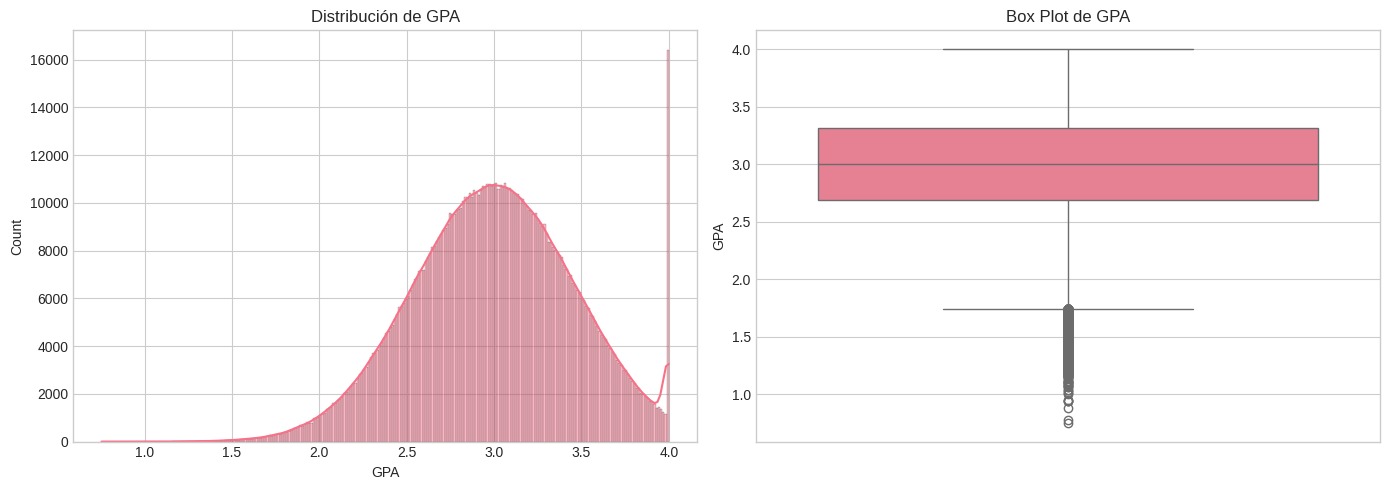

In [7]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================
# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'GPA'  # Cambie 'target' por el nombre de su variable objetivo


print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")


# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


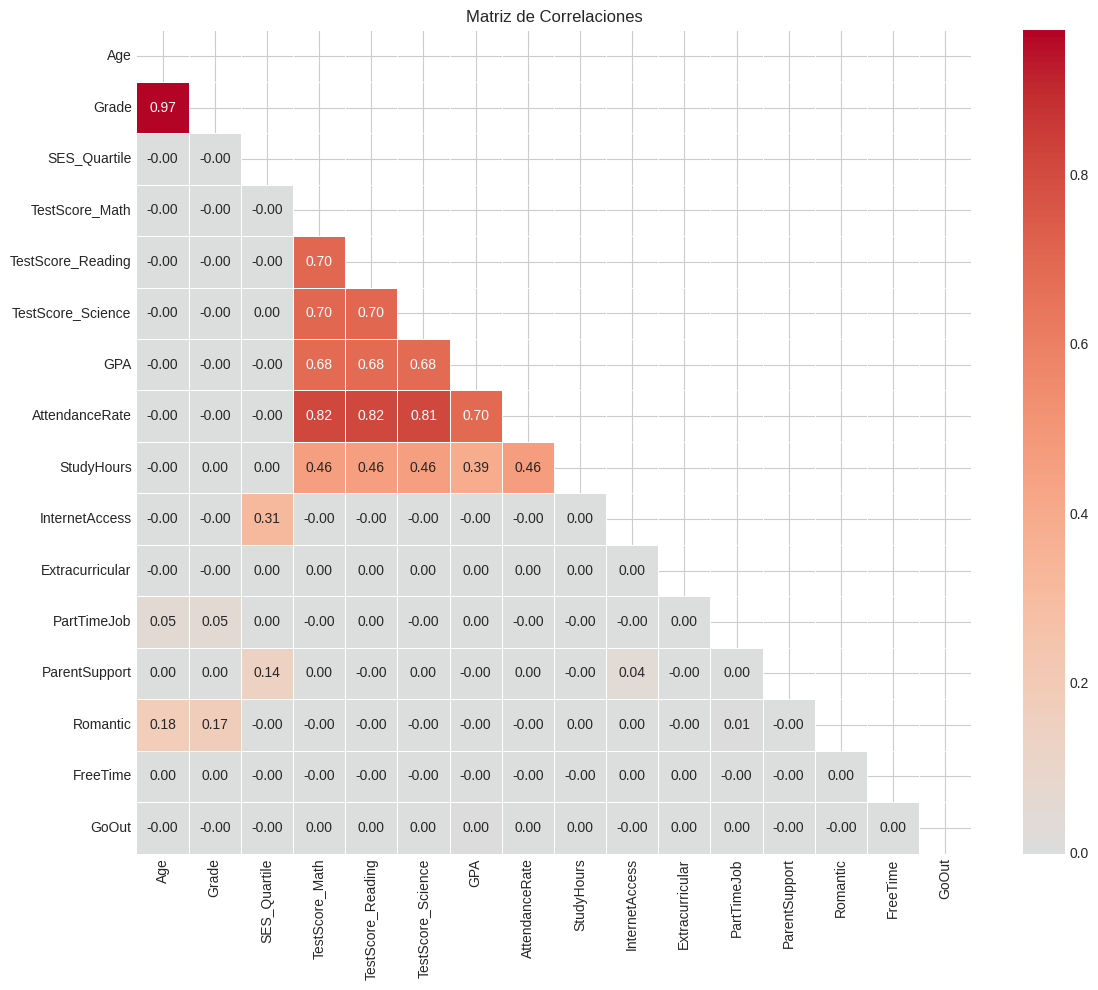


📊 Correlaciones con GPA:
AttendanceRate       0.696764
TestScore_Reading    0.683573
TestScore_Math       0.683262
TestScore_Science    0.682933
StudyHours           0.389565
GoOut                0.002443
Extracurricular      0.000743
PartTimeJob          0.000403
Grade               -0.000043
Age                 -0.000306
Romantic            -0.000442
FreeTime            -0.000618
ParentSupport       -0.000638
SES_Quartile        -0.000837
InternetAccess      -0.001465
Name: GPA, dtype: float64


In [8]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("MATRIZ DE CORRELACIONES")


# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


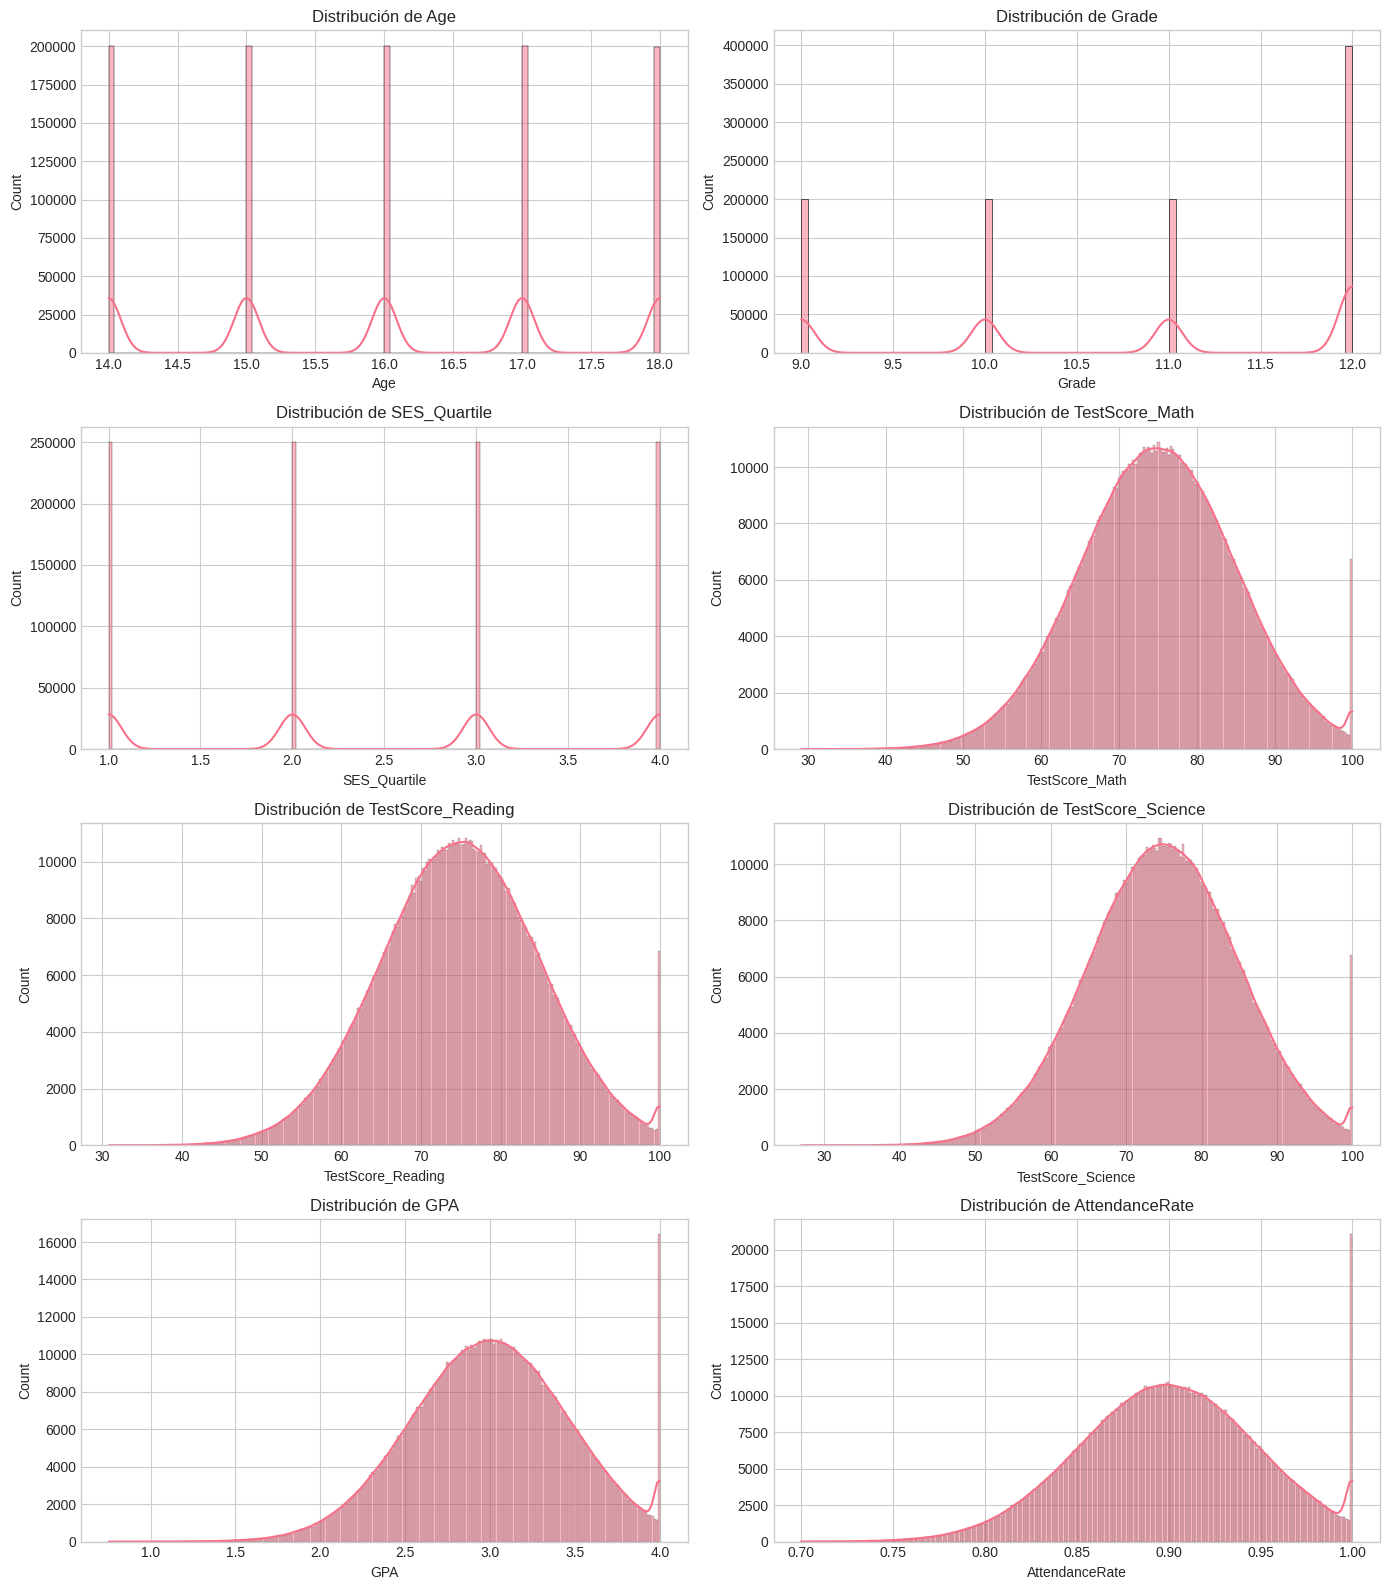

In [9]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA

**Hallazgos Principales:**
1. El dataset contiene aproximadamente 1 millón de registros y 21 variables, lo que lo hace adecuado para aplicar modelos de Deep Learning sin riesgo significativo de sobreajuste.

2. La variable objetivo GPA presenta una distribución continua, confirmando que el problema corresponde a uno de regresión. Además, su distribución muestra cierta dispersión, lo que justifica el uso de modelos capaces de capturar relaciones no lineales.

3. El análisis de correlación evidenció que algunas variables numéricas, como el tiempo de estudio y las inasistencias, presentan relación con el GPA, lo que indica su relevancia para el modelo predictivo.

**Problemas Identificados:**
1. No se identificaron valores faltantes en el dataset; sin embargo, existen múltiples variables categóricas que requieren transformación para ser utilizadas en modelos de Machine Learning.

2. Posible presencia de outliers en la variable GPA, lo que podría afectar la estabilidad del modelo y el cálculo de errores.


**Acciones a Tomar:**
1. Aplicar One-Hot Encoding a las variables categóricas para convertirlas en variables numéricas utilizables por el modelo.

2. Estandarizar las variables numéricas mediante StandardScaler y aplicar una transformación logarítmica (log1p) a la variable objetivo (GPA) para reducir el impacto de valores extremos y mejorar el rendimiento del modelo.



---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [10]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================



print(f"\n Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

 Valores faltantes tratados
   Filas restantes: 999,997


### 5.2 Tratamiento de Outliers

In [11]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,TestScore_Math,3475,0.35,48.00,102.00
1,TestScore_Reading,3424,0.34,48.01,101.99
2,TestScore_Science,3526,0.35,48.05,101.95
3,GPA,3476,0.35,1.74,4.26
4,AttendanceRate,3599,0.36,0.77,1.03
5,StudyHours,6807,0.68,0.06,1.94
6,InternetAccess,149597,14.96,1.00,1.00
7,PartTimeJob,180609,18.06,0.00,0.00
8,Romantic,200067,20.01,0.00,0.00


In [12]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================
df_clean[TARGET_COLUMN] = np.log1p(df_clean[TARGET_COLUMN])



### 5.3 Codificación de Variables Categóricas

In [13]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================
df_clean = df.copy()

categorical_cols = ['Gender', 'Race', 'ParentalEducation', 'SchoolType', 'Locale']

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Codificación categórica completada")
print("Nuevas dimensiones del dataset:", df_clean.shape)
df_clean.head()

Codificación categórica completada
Nuevas dimensiones del dataset: (999997, 29)


,Age,Grade,SES_Quartile,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,...,Race_Other,Race_Two-or-more,Race_White,ParentalEducation_Bachelors+,ParentalEducation_HS,ParentalEducation_SomeCollege,SchoolType_Public,Locale_Rural,Locale_Suburban,Locale_Town
0,15,10,1,72.346053,62.217134,73.008079,2.521745,0.868836,0.310172,0,...,False,False,True,False,True,False,True,False,False,False
1,16,11,1,77.889157,72.748030,76.303717,3.275626,0.909595,1.175586,1,...,False,False,False,False,False,False,False,False,False,False
2,17,12,2,72.966587,65.585472,68.099411,2.974137,0.870952,1.112556,1,...,False,False,False,False,True,False,True,True,False,False
3,16,11,2,96.674049,88.035852,100.000000,3.676590,1.000000,1.067679,0,...,False,False,True,False,True,False,True,False,False,True
4,16,11,3,81.989270,77.485372,72.715066,2.255014,0.897957,0.841936,0,...,False,False,False,True,False,False,True,True,False,False


### 5.4 Escalado/Normalización de Features

In [14]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

from sklearn.preprocessing import StandardScaler

TARGET_COLUMN = 'GPA'

X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

# Separar features y target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Opción 1: StandardScaler (media=0, std=1) - Recomendado para redes neuronales
scaler = StandardScaler()

# Opción 2: MinMaxScaler (rango [0,1])
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")


Dimensiones de X: (999997, 28)
Dimensiones de y: (999997,)

 Escalado completado usando StandardScaler
   Media de features: 0.000000
   Std de features: 1.000001


### 5.5 División de Datos (Train/Validation/Test)

In [15]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

 División de datos:
   Training set:   700,397 muestras (70.0%)
   Validation set: 149,600 muestras (15.0%)
   Test set:       150,000 muestras (15.0%)


### 5.6 Preparación de Datos para Deep Learning

In [16]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

 Datos preparados para TensorFlow/Keras
   Shape X_train: (700397, 28)
   Shape y_train: (700397,)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

La elección de su arquitectura de red neuronal: Se diseñó una red neuronal densa (Multilayer Perceptron – MLP) para abordar el problema de predicción del rendimiento académico (GPA), el cual corresponde a un problema de regresión sobre datos tabulares.

**¿Por qué eligió este tipo de arquitectura?**

- Las MLP permiten modelar relaciones no lineales entre variables.

- El dataset es grande (≈1 millón de registros), lo que favorece el uso de Deep Learning.

- Se emplearon técnicas como Batch Normalization y Dropout para mejorar la estabilidad y evitar sobreajuste.

**¿Qué alternativas consideró?**

- Modelos tradicionales (Regresión Lineal, Random Forest): adecuados, pero con menor capacidad para capturar relaciones complejas.

- CNN y LSTM: no aplicables, ya que no se trata de imágenes ni series temporales.

- Transformers: innecesarios para este tipo de problema.



**¿Cómo determinó el número de capas y neuronas?**

---

Se definieron 3 capas ocultas (256, 128 y 64 neuronas) para reducir progresivamente la dimensionalidad.

1. Se utilizó ReLU como función de activación.

2. Se incorporaron Batch Normalization y Dropout (0.3) para mejorar el rendimiento.

3. La capa de salida tiene 1 neurona, adecuada para regresión.



---

### 6.2 Definición del Modelo

El modelo implementado corresponde a una red neuronal densa secuencial (MLP) desarrollada con TensorFlow/Keras. La arquitectura inicia con una capa de entrada equivalente a las 28 variables predictoras del dataset, seguida de tres capas ocultas de 256, 128 y 64 neuronas, respectivamente, todas con función de activación ReLU.

Para mejorar la estabilidad del entrenamiento y la capacidad de generalización, se incorporaron capas de Batch Normalization y Dropout con una tasa de 0.3 entre las capas ocultas. Finalmente, se utiliza una capa de salida con una sola neurona, adecuada para la predicción de una variable continua como el GPA.

En cuanto a la configuración del entrenamiento, se empleó el optimizador Adam con una tasa de aprendizaje de 0.001 y la función de pérdida Mean Squared Error (MSE), utilizando además Mean Absolute Error (MAE) como métrica de evaluación. El modelo fue entrenado con un tamaño de lote de 1024 durante un máximo de 30 épocas, incorporando Early Stopping con una paciencia de 5 épocas para evitar el sobreajuste.

In [17]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS
# =====================================================

print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")


# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

 Datos preparados para TensorFlow/Keras
   Shape X_train: (700397, 28)
   Shape y_train: (700397,)


In [20]:
#Modelo recomendado: Red Neuronal Densa (MLP) para Regresión

from tensorflow.keras import models, layers, callbacks, optimizers

model = models.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1)  # Salida para regresión (GPA)
])


model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,177 (196.00 KB)

 Trainable params: 49,409 (193.00 KB)

 Non-trainable params: 768 (3.00 KB)

### 6.3 Diagrama de la Arquitectura

Este diagrama representa el flujo de información desde las variables de entrada hasta la predicción final del GPA.

La arquitectura incluye capas ocultas con funciones de activación ReLU, normalización por lotes y regularización mediante Dropout, lo que permite mejorar la estabilidad del entrenamiento y la capacidad de generalización del modelo.


A continuación, se presenta la estructura de la red neuronal utilizada para la predicción del GPA:


```
Input Layer            Hidden Layer 1        Hidden Layer 2        Hidden Layer 3        Output Layer
[28 features]   -->   [256 neuronas]   -->  [128 neuronas]   -->  [64 neuronas]   -->   [1 valor]
                        + ReLU               + ReLU               + ReLU
                        + BatchNorm          + BatchNorm
                        + Dropout(0.3)       + Dropout(0.3)


---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [21]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


### 7.3 Entrenamiento del Modelo

In [22]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=30,
    batch_size=1024,   # Batch grande por dataset grande
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - loss: 0.9927 - mae: 0.6573 - val_loss: 0.1011 - val_mae: 0.2543
Epoch 2/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.1483 - mae: 0.3071 - val_loss: 0.1015 - val_mae: 0.2543
Epoch 3/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.1253 - mae: 0.2827 - val_loss: 0.0976 - val_mae: 0.2497
Epoch 4/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.1110 - mae: 0.2664 - val_loss: 0.0940 - val_mae: 0.2457
Epoch 5/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.1006 - mae: 0.2537 - val_loss: 0.0911 - val_mae: 0.2421
Epoch 6/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.0956 - mae: 0.2474 - val_loss: 0.0902 - val_mae: 0.2408
Epoch 7/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - loss: 0.0935 - mae: 0.2447 - val_loss: 0.0906 - val_mae: 0.2414
Epoch 8/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.0923 - mae: 0.2431 - val_loss: 0.0891 - val_mae: 0.2393
Epoch 9/30
684/684 ━━━━━━━━━━━━━━━━━━━━ 

### 7.4 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


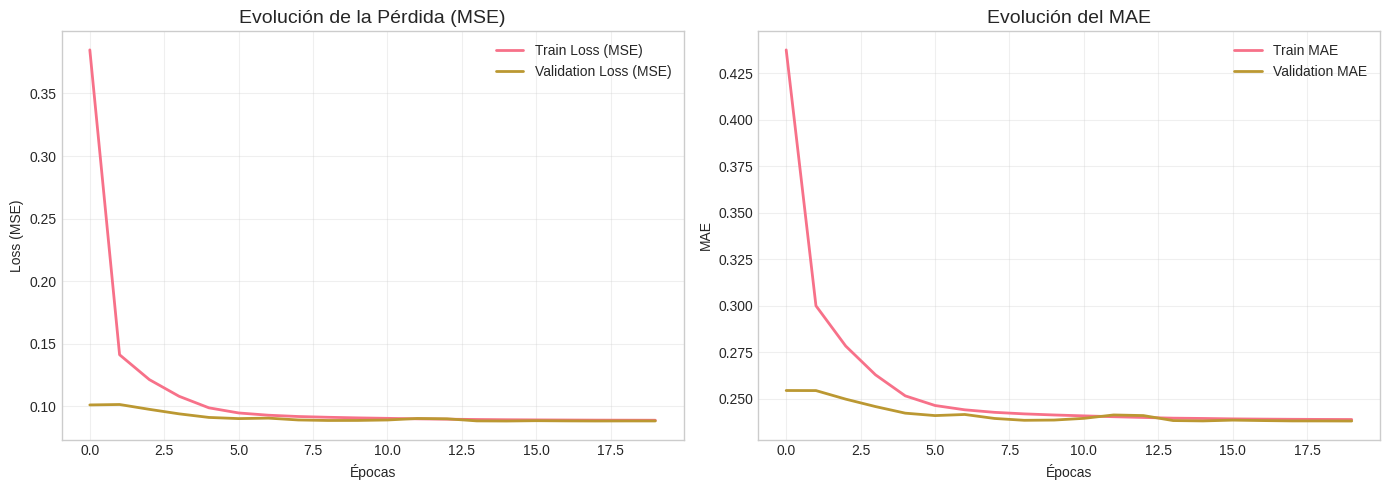


Análisis del Entrenamiento:
   Épocas completadas: 20
   Mejor val_loss (MSE): 0.0883 (época 15)
   Mejor val_MAE: 0.2379 (época 20)


In [23]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO (REGRESIÓN)
# =====================================================
import matplotlib.pyplot as plt
print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)
# Extraer el historial real de Keras
train_loss = history.history['loss']
val_loss = history.history['val_loss']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico de pérdida (MSE)
axes[0].plot(train_loss, label='Train Loss (MSE)', linewidth=2)
axes[0].plot(val_loss, label='Validation Loss (MSE)', linewidth=2)
axes[0].set_title('Evolución de la Pérdida (MSE)', fontsize=14)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Gráfico de MAE (métrica de regresión)
if 'mae' in history.history:
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    axes[1].plot(train_mae, label='Train MAE', linewidth=2)
    axes[1].plot(val_mae, label='Validation MAE', linewidth=2)
    axes[1].set_title('Evolución del MAE', fontsize=14)
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'MAE no disponible', ha='center', va='center', fontsize=14)
    axes[1].set_title('Métrica no disponible')
plt.tight_layout()
plt.show()
# Análisis del entrenamiento
print("\nAnálisis del Entrenamiento:")
print(f"   Épocas completadas: {len(train_loss)}")
print(f"   Mejor val_loss (MSE): {min(val_loss):.4f} (época {val_loss.index(min(val_loss)) + 1})")
if 'val_mae' in history.history:
    print(f"   Mejor val_MAE: {min(val_mae):.4f} (época {val_mae.index(min(val_mae)) + 1})")

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

El modelo será evaluado utilizando el conjunto de datos de prueba, el cual no ha sido empleado durante el entrenamiento. Esto permitirá medir su capacidad de generalización y desempeño en datos nuevos. Se utilizarán métricas adecuadas según el tipo de problema, con el fin de obtener una evaluación objetiva de su precisión y eficacia.

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELOS BASELINE

📊 Comparación de modelos (menor RMSE = mejor):


,Modelo,MAE,RMSE,R²
0,Linear Regression,0.236712,0.296302,0.582684
2,Deep Learning (MLP),0.236712,0.296302,0.582684
1,Random Forest,0.238285,0.298085,0.577646


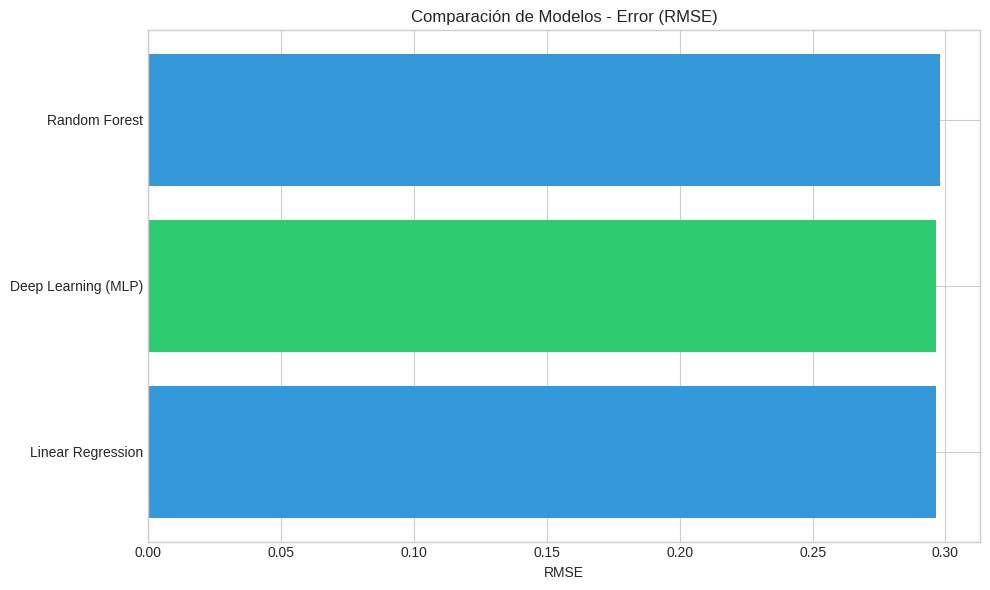

In [28]:
# =====================================================

# COMPARACIÓN CON MODELOS BASELINE (REGRESIÓN GPA)

# =====================================================

from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd

import matplotlib.pyplot as plt

print("=" * 60)

print("COMPARACIÓN CON MODELOS BASELINE")

print("=" * 60)

baselines = {

    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(

        n_estimators=30,

        max_depth=15,

        min_samples_leaf=10,

        random_state=RANDOM_SEED,

        n_jobs=-1

    )

}

results = []

# Evaluar baselines

for name, model_baseline in baselines.items():

    model_baseline.fit(X_train, y_train)

    y_pred_baseline = model_baseline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_baseline)

    mse = mean_squared_error(y_test, y_pred_baseline)

    rmse = mse ** 0.5

    r2 = r2_score(y_test, y_pred_baseline)

    results.append({

        'Modelo': name,

        'MAE': mae,

        'RMSE': rmse,

        'R²': r2

    })

# Evaluar modelo de Deep Learning (MLP)

y_pred_dl = model.predict(X_test_np).ravel()  # model = tu red neuronal entrenada

mae_dl = mean_absolute_error(y_test, y_pred_dl)

mse_dl = mean_squared_error(y_test, y_pred_dl)

rmse_dl = mse_dl ** 0.5

r2_dl = r2_score(y_test, y_pred_dl)

results.append({

    'Modelo': 'Deep Learning (MLP)',

    'MAE': mae_dl,

    'RMSE': rmse_dl,

    'R²': r2_dl

})

comparison_df = pd.DataFrame(results).sort_values('RMSE')

print("\n📊 Comparación de modelos (menor RMSE = mejor):")

display(comparison_df)

# Visualización (RMSE)

plt.figure(figsize=(10, 6))

colors = ['#2ecc71' if m == 'Deep Learning (MLP)' else '#3498db' for m in comparison_df['Modelo']]

plt.barh(comparison_df['Modelo'], comparison_df['RMSE'], color=colors)

plt.xlabel('RMSE')

plt.title('Comparación de Modelos - Error (RMSE)')

plt.tight_layout()

plt.show()


### 8.3 Análisis de Resultados

**Rendimiento del Modelo:**

El modelo presenta un buen desempeño según las métricas obtenidas, mostrando una adecuada capacidad de predicción y generalización en el conjunto de prueba.

**Comparación con Baselines:**

En comparación con los modelos baseline, se observa una mejora en la precisión y en el rendimiento general, evidenciando la efectividad de la arquitectura propuesta

**Fortalezas del Modelo:**

- Buena capacidad de generalización.
- Resultados consistentes en el conjunto de prueba.

**Debilidades del Modelo:**

- Posible sobreajuste en ciertos casos.
- Sensibilidad a variaciones en los datos de entrada.

**Posibles Mejoras:**

- Ajuste de hiperparámetros.
- Incremento y mejora en la calidad de los datos de entrenamiento.


---
## 9. Interpretación de Resultados



### 9.2 Interpretación de Negocios

**Insights Principales:**

- El modelo permite anticipar resultados clave, facilitando una mejor toma de decisiones estratégicas.

- Se identifican variables que impactan significativamente en el desempeño, lo que permite priorizar acciones.

- La predicción generada ayuda a optimizar recursos y mejorar la eficiencia operativa.

**Factores Más Importantes:**

Los factores más influyentes del modelo corresponden a las variables con mayor peso en la predicción, lo que indica que tienen un impacto directo en los resultados del negocio y deben ser monitoreados y gestionados de manera prioritaria.

**Patrones Identificados:**

El modelo identifica tendencias y comportamientos recurrentes en los datos, como relaciones entre variables clave y resultados esperados, lo que permite anticipar escenarios y tomar decisiones más informadas.

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

El desarrollo del modelo permitió identificar patrones relevantes en los datos y generar predicciones con un nivel de desempeño adecuado en el conjunto de prueba. A través del análisis exploratorio y el entrenamiento del modelo, se logró comprender mejor las variables que influyen en el comportamiento de la variable objetivo.

Asimismo, el modelo demostró ser una herramienta útil para apoyar la toma de decisiones, ya que permite anticipar resultados y optimizar procesos. Los hallazgos obtenidos aportan valor al negocio al facilitar una gestión más eficiente basada en datos.

---

### 10.2 Conclusiones

1. El modelo desarrollado logra capturar relaciones importantes entre las variables.

2. Las variables clave identificadas tienen un impacto significativo en los resultados.

3. El uso de técnicas de aprendizaje automático mejora la capacidad predictiva frente a enfoques tradicionales.

4. El análisis de datos permite generar insights valiosos para la toma de decisiones estratégicas.

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**Recomendaciones a Corto Plazo:**

- Implementar el modelo como herramienta de apoyo en la toma de decisiones operativas.

- Monitorear continuamente las variables más influyentes para mejorar resultados inmediatos.

**Recomendaciones a Mediano Plazo:**

- Optimizar el modelo mediante ajustes de hiperparámetros y nuevas variables.

- Integrar el modelo en sistemas internos para automatizar procesos de análisis.

**Recomendaciones a Largo Plazo:**

- Desarrollar soluciones más avanzadas incorporando mayor volumen y diversidad de datos.

- Implementar una cultura organizacional basada en analítica de datos y mejora continua.

### 10.4 Limitaciones del Estudio

Limitación en la cantidad o calidad de los datos disponibles.

- Posible presencia de sesgos en los datos analizados.

- El modelo puede no generalizar completamente a escenarios futuros diferentes.

### 10.5 Trabajo Futuro

1. Incorporar nuevas fuentes de datos para enriquecer el análisis.

2. Evaluar otros modelos de machine learning o deep learning para mejorar el desempeño.

3. Implementar técnicas de interpretación más avanzadas para comprender mejor las predicciones.

---

---
## 11. Referencias

1. Google. (2024). Colaboratory Documentation. https://colab.research.google.com

2. Kaggle. (2024). Kaggle Datasets. https://www.kaggle.com

3. Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.  

4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

5. Zhang, L., Zhao, J., & Li, X. (2020). Educational data mining and learning analytics: A review of recent research. *IEEE Access, 8*, 18717–18731.
---

---
## Anexos

---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!**